In [1]:
import pandas as pd
import numpy as np
!pip install xgboost

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Lead Scoring.csv to Lead Scoring.csv


In [3]:
df = pd.read_csv("Lead Scoring.csv")

df.head()

original_df = df.copy()

In [4]:
selected_features = [
    "TotalVisits",
    "Total Time Spent on Website",
    "Page Views Per Visit",
    "Converted"
]

df = df[selected_features]

df.head()

,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Converted
0,0.0,0,0.0,0
1,5.0,674,2.5,0
2,2.0,1532,2.0,1
3,1.0,305,1.0,0
4,2.0,1428,1.0,1


In [5]:
# Average time spent per visit
df["TimePerVisit"] = (
    df["Total Time Spent on Website"] /
    (df["TotalVisits"] + 1)
)

# Engagement feature
df["EngagementScore"] = (
    df["TotalVisits"] *
    df["Page Views Per Visit"]
)

df.head()

,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Converted,TimePerVisit,EngagementScore
0,0.0,0,0.0,0,0.000000,0.0
1,5.0,674,2.5,0,112.333333,12.5
2,2.0,1532,2.0,1,510.666667,4.0
3,1.0,305,1.0,0,152.500000,1.0
4,2.0,1428,1.0,1,476.000000,2.0


In [6]:
df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9103 entries, 0 to 9239
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   TotalVisits                  9103 non-null   float64
 1   Total Time Spent on Website  9103 non-null   int64  
 2   Page Views Per Visit         9103 non-null   float64
 3   Converted                    9103 non-null   int64  
 4   TimePerVisit                 9103 non-null   float64
 5   EngagementScore              9103 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 497.8 KB


In [7]:
model_features = [
    "TotalVisits",
    "Total Time Spent on Website",
    "Page Views Per Visit",
    "EngagementScore",
    "TimePerVisit"
]

X = df[model_features]

y = df["Converted"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 7282
Testing samples: 1821


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Train Logistic Regression

In [10]:
log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train_scaled, y_train)

log_reg_predictions = log_reg.predict(X_test_scaled)
log_reg_probabilities = log_reg.predict_proba(X_test_scaled)[:, 1]

## Evaluate Logistic Regression

In [11]:
log_reg_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, log_reg_predictions),
    "Precision": precision_score(y_test, log_reg_predictions),
    "Recall": recall_score(y_test, log_reg_predictions),
    "F1-score": f1_score(y_test, log_reg_predictions),
    "ROC-AUC": roc_auc_score(y_test, log_reg_probabilities)
}

log_reg_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.7287204832509611,
 'Precision': 0.7051597051597052,
 'Recall': 0.4341906202723147,
 'F1-score': 0.5374531835205992,
 'ROC-AUC': np.float64(0.7738353591736659)}

## Train Random Forest

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

## Evaluate Random Forest

In [13]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_predictions),
    "Precision": precision_score(y_test, rf_predictions),
    "Recall": recall_score(y_test, rf_predictions),
    "F1-score": f1_score(y_test, rf_predictions),
    "ROC-AUC": roc_auc_score(y_test, rf_probabilities)
}

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.6880834706205382,
 'Precision': 0.6004319654427646,
 'Recall': 0.4205748865355522,
 'F1-score': 0.49466192170818507,
 'ROC-AUC': np.float64(0.7178289164797329)}

## TRAIN XGBOOST

In [14]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

xgb_probabilities = xgb_model.predict_proba(X_test)[:, 1]

## EVALUATE XGBOOST

In [15]:
xgb_results = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_predictions),
    "Precision": precision_score(y_test, xgb_predictions),
    "Recall": recall_score(y_test, xgb_predictions),
    "F1-score": f1_score(y_test, xgb_predictions),
    "ROC-AUC": roc_auc_score(y_test, xgb_probabilities)
}

xgb_results

{'Model': 'XGBoost',
 'Accuracy': 0.7473915431081823,
 'Precision': 0.7072164948453609,
 'Recall': 0.518910741301059,
 'F1-score': 0.5986038394415357,
 'ROC-AUC': np.float64(0.7835117898690593)}

## Compare Models

In [16]:
results_df = pd.DataFrame([
    log_reg_results,
    rf_results,
    xgb_results
])

results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.728720,0.705160,0.434191,0.537453,0.773835
1,Random Forest,0.688083,0.600432,0.420575,0.494662,0.717829
2,XGBoost,0.747392,0.707216,0.518911,0.598604,0.783512


##Visualize Comparison

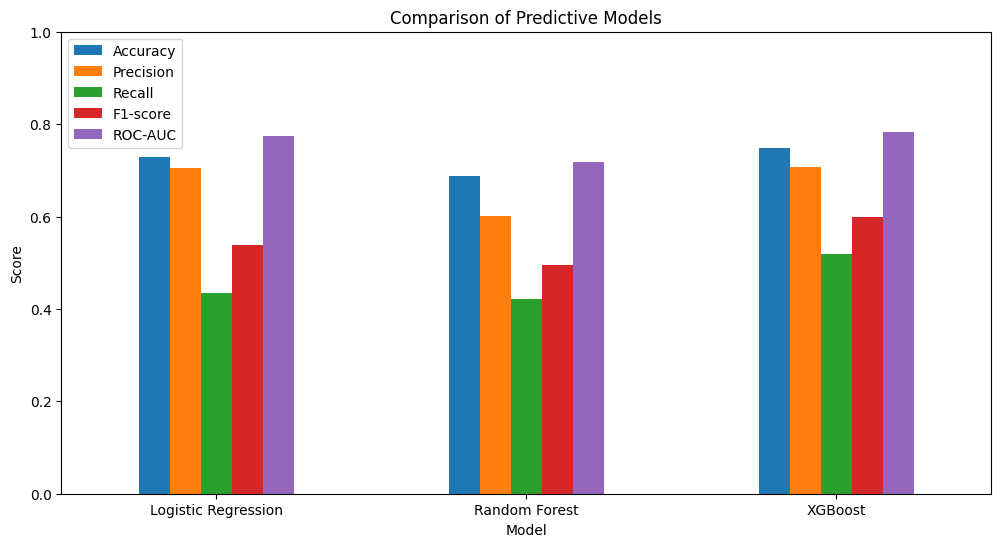

In [17]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparison of Predictive Models")
plt.ylabel("Score")
plt.ylim(0,1)

plt.xticks(rotation=0)

plt.show()

### Comparing Predictive Models

To answer RQ2, three different machine learning models were trained and evaluated:

- Logistic Regression
- Random Forest
- XGBoost

The purpose of this comparison was to investigate how different modelling approaches influence lead prioritisation and conversion prediction performance.

Logistic Regression was included as an interpretable baseline model, while Random Forest and XGBoost were selected as ensemble-based approaches capable of capturing more complex patterns within the data.

The models were evaluated using the following metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

These metrics were selected to provide a broader understanding of model performance beyond simple classification accuracy.

In the context of lead prioritisation, metrics such as recall and F1-score are particularly important, since the objective is not only to classify leads correctly, but also to identify as many potentially valuable leads as possible.

The results showed that XGBoost achieved the strongest overall performance across most evaluation metrics. In particular, the model obtained the highest accuracy, recall, F1-score, and ROC-AUC values among the tested approaches.

Logistic Regression still performed reasonably well and provided a useful interpretable baseline. However, its lower recall suggests that fewer converted leads were identified compared to XGBoost.

Random Forest achieved the weakest overall performance in this comparison, with lower scores across most evaluation metrics.

Overall, the findings indicate that ensemble-based boosting methods such as XGBoost may be more effective for identifying high-value leads and supporting data-driven lead prioritisation strategies within CRM systems.

## Create priority labels

In [18]:
best_probabilities = xgb_probabilities

priority_df = pd.DataFrame({
    "Probability": best_probabilities
})

def assign_priority(prob):
    if prob >= 0.70:
        return "High Priority"

    elif prob >= 0.40:
        return "Medium Priority"

    else:
        return "Low Priority"

priority_df["Priority"] = priority_df["Probability"].apply(assign_priority)

priority_df.head()

,Probability,Priority
0,0.058629,Low Priority
1,0.163813,Low Priority
2,0.421529,Medium Priority
3,0.186784,Low Priority
4,0.144781,Low Priority


In [19]:
priority_df["Priority"].value_counts()

,count
Priority,
Low Priority,843
Medium Priority,723
High Priority,255


## Visualization

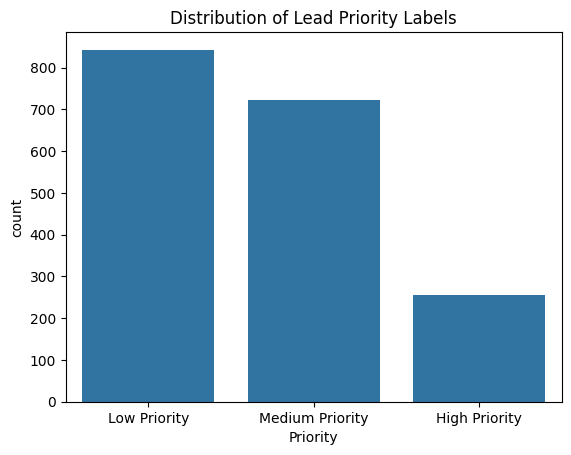

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=priority_df,
    x="Priority"
)

plt.title("Distribution of Lead Priority Labels")

plt.show()

### Lead Prioritisation Logic

To support CRM decision-making, the predicted conversion probabilities generated by the best-performing model were transformed into business-oriented priority labels.

The following thresholds were applied:

- High Priority: probability ≥ 0.70
- Medium Priority: probability between 0.40 and 0.69
- Low Priority: probability < 0.40

This transformation allows model predictions to be interpreted more easily within a CRM context, where marketing and sales teams require actionable categories rather than raw probabilities.

High-priority leads represent users with strong predicted conversion likelihood and may therefore require immediate follow-up actions. Medium-priority leads may benefit from additional marketing communication or nurturing strategies, while low-priority leads may require lower levels of direct sales engagement.

The prioritisation logic demonstrates how predictive model outputs can support operational lead management and data-driven CRM workflows.

# Save Models and Metrics

In [21]:
import joblib

joblib.dump(xgb_model, "xgboost_model.pkl")

results_df.to_csv("model_results.csv", index=False)

In [22]:
from google.colab import files

files.download("xgboost_model.pkl")
files.download("model_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Supporting Lead Prioritisation Through Predictive Modelling

The predictive models developed in this analysis were designed not only to estimate conversion likelihood, but also to support practical lead prioritisation within CRM workflows.

Rather than treating all leads equally, the models generate probability scores that indicate how likely each lead is to convert. These probabilities can subsequently be transformed into business-oriented priority categories such as:

- High Priority
- Medium Priority
- Low Priority

This enables marketing and sales teams to focus resources on leads with the highest predicted conversion potential.

The model comparison further demonstrated that different machine learning approaches influence prediction performance differently. In this analysis, XGBoost achieved the strongest overall performance across most evaluation metrics, particularly recall, F1-score, and ROC-AUC.

From a CRM perspective, recall is especially important because it reflects the model’s ability to identify potentially valuable leads. A higher recall reduces the risk of overlooking leads with strong conversion potential, while F1-score provides a balanced measure between precision and recall.

The resulting prioritisation logic allows the predictive system to support several operational CRM tasks, including:

- prioritising sales outreach
- identifying high-value prospects
- supporting marketing segmentation
- reducing time spent on low-potential leads
- enabling more targeted communication strategies

Overall, the findings demonstrate how predictive modelling can contribute to more data-driven lead management processes by transforming behavioral data into actionable prioritisation insights.

In [23]:
import joblib

joblib.dump(xgb_model, "xgboost_model.pkl")

['xgboost_model.pkl']

In [24]:
from google.colab import files

files.download("xgboost_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
from google.colab import files

files.download("model_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ----------------------------------
# RQ3: Build recommendation dataframe
# ----------------------------------

In [90]:
# ----------------------------------
# RQ3: Build CRM recommendation dataframe
# ----------------------------------

rq3_df = original_df.loc[X.index].copy()

rq3_df["TimePerVisit"] = X["TimePerVisit"]
rq3_df["EngagementScore"] = X["EngagementScore"]

# Use trained XGBoost model from RQ2
rq3_df["PredictedProbability"] = xgb_model.predict_proba(X)[:, 1]

rq3_df[[
    "Lead Source",
    "Do Not Email",
    "Do Not Call",
    "PredictedProbability"
]].head()

,Lead Source,Do Not Email,Do Not Call,PredictedProbability
0,Olark Chat,No,No,0.421529
1,Organic Search,No,No,0.499739
2,Direct Traffic,No,No,0.742419
3,Direct Traffic,No,No,0.051493
4,Google,No,No,0.739126


## Priority logic

In [91]:
# ----------------------------------
# Priority Logic
# ----------------------------------

def assign_priority(probability):
    if probability >= 0.70:
        return "High Priority"
    elif probability >= 0.40:
        return "Medium Priority"
    else:
        return "Low Priority"


rq3_df["Priority"] = rq3_df["PredictedProbability"].apply(assign_priority)

rq3_df[[
    "PredictedProbability",
    "Priority"
]].head()

,PredictedProbability,Priority
0,0.421529,Medium Priority
1,0.499739,Medium Priority
2,0.742419,High Priority
3,0.051493,Low Priority
4,0.739126,High Priority


## Contact permission status

In [92]:
# ----------------------------------
# Contact Permission Status
# ----------------------------------

def contact_permission_status(row):

    if row["Do Not Email"] == "Yes" and row["Do Not Call"] == "Yes":
        return "No direct contact allowed"

    elif row["Do Not Email"] == "Yes":
        return "Email restricted"

    elif row["Do Not Call"] == "Yes":
        return "Phone restricted"

    else:
        return "Direct contact allowed"


rq3_df["ContactPermissionStatus"] = rq3_df.apply(
    contact_permission_status,
    axis=1
)

rq3_df[[
    "Do Not Email",
    "Do Not Call",
    "ContactPermissionStatus"
]].head()

,Do Not Email,Do Not Call,ContactPermissionStatus
0,No,No,Direct contact allowed
1,No,No,Direct contact allowed
2,No,No,Direct contact allowed
3,No,No,Direct contact allowed
4,No,No,Direct contact allowed


## Recommendation category

In [93]:
# ----------------------------------
# Recommendation Category
# ----------------------------------

def assign_recommendation_category(row):

    priority = row["Priority"]
    contact_status = row["ContactPermissionStatus"]

    if priority == "High Priority" and contact_status == "Direct contact allowed":
        return "Immediate Sales Follow-up"

    elif priority == "High Priority" and contact_status != "Direct contact allowed":
        return "Compliant Alternative Follow-up"

    elif priority == "Medium Priority":
        return "Targeted Nurturing"

    else:
        return "Automated Low-Intensity Marketing"


rq3_df["RecommendationCategory"] = rq3_df.apply(
    assign_recommendation_category,
    axis=1
)

rq3_df[[
    "Priority",
    "ContactPermissionStatus",
    "RecommendationCategory"
]].head()

,Priority,ContactPermissionStatus,RecommendationCategory
0,Medium Priority,Direct contact allowed,Targeted Nurturing
1,Medium Priority,Direct contact allowed,Targeted Nurturing
2,High Priority,Direct contact allowed,Immediate Sales Follow-up
3,Low Priority,Direct contact allowed,Automated Low-Intensity Marketing
4,High Priority,Direct contact allowed,Immediate Sales Follow-up


In [94]:
# ----------------------------------
# AGENT 1: Marketing Agent
# ----------------------------------

def marketing_agent(row):

    source = row["Lead Source"]
    probability = row["PredictedProbability"]
    priority = row["Priority"]

    if priority == "High Priority":
        return (
            f"Marketing Agent: Lead from {source} has high conversion potential "
            f"({probability:.1%}). Recommend personalised messaging and campaign reinforcement."
        )

    elif priority == "Medium Priority":
        return (
            f"Marketing Agent: Lead from {source} has moderate conversion potential "
            f"({probability:.1%}). Recommend targeted nurturing to increase engagement."
        )

    else:
        return (
            f"Marketing Agent: Lead from {source} has low conversion potential "
            f"({probability:.1%}). Recommend automated low-intensity marketing."
        )


rq3_df["MarketingAgentSuggestion"] = rq3_df.apply(
    marketing_agent,
    axis=1
)

rq3_df[["MarketingAgentSuggestion"]].head()

,MarketingAgentSuggestion
0,Marketing Agent: Lead from Olark Chat has mode...
1,Marketing Agent: Lead from Organic Search has ...
2,Marketing Agent: Lead from Direct Traffic has ...
3,Marketing Agent: Lead from Direct Traffic has ...
4,Marketing Agent: Lead from Google has high con...


In [95]:
# ----------------------------------
# AGENT 2: Sales Agent
# ----------------------------------

def sales_agent(row):

    priority = row["Priority"]
    probability = row["PredictedProbability"]
    contact_status = row["ContactPermissionStatus"]

    if priority == "High Priority" and contact_status == "Direct contact allowed":
        return (
            f"Sales Agent: Lead should be contacted immediately. "
            f"Predicted conversion probability is {probability:.1%}, and direct contact is allowed."
        )

    elif priority == "High Priority" and contact_status != "Direct contact allowed":
        return (
            f"Sales Agent: Lead has high conversion potential ({probability:.1%}), "
            f"but contact restrictions apply: {contact_status}. Recommend compliant alternative follow-up."
        )

    elif priority == "Medium Priority":
        return (
            "Sales Agent: Direct sales outreach should be postponed. "
            "Lead should be nurtured until stronger buying signals are observed."
        )

    else:
        return (
            "Sales Agent: Lead should not receive direct sales prioritisation at this stage."
        )


rq3_df["SalesAgentSuggestion"] = rq3_df.apply(
    sales_agent,
    axis=1
)

rq3_df[["SalesAgentSuggestion"]].head()

,SalesAgentSuggestion
0,Sales Agent: Direct sales outreach should be p...
1,Sales Agent: Direct sales outreach should be p...
2,Sales Agent: Lead should be contacted immediat...
3,Sales Agent: Lead should not receive direct sa...
4,Sales Agent: Lead should be contacted immediat...


In [96]:
# ----------------------------------
# Human-in-the-Loop Status
# ----------------------------------

def human_in_the_loop_status(row):

    if row["Priority"] == "High Priority":
        return "Requires marketing/sales approval"

    elif row["ContactPermissionStatus"] != "Direct contact allowed":
        return "Requires compliance review"

    else:
        return "Can be processed automatically"


rq3_df["HumanInTheLoopStatus"] = rq3_df.apply(
    human_in_the_loop_status,
    axis=1
)

rq3_df[[
    "Priority",
    "ContactPermissionStatus",
    "HumanInTheLoopStatus"
]].head()

,Priority,ContactPermissionStatus,HumanInTheLoopStatus
0,Medium Priority,Direct contact allowed,Can be processed automatically
1,Medium Priority,Direct contact allowed,Can be processed automatically
2,High Priority,Direct contact allowed,Requires marketing/sales approval
3,Low Priority,Direct contact allowed,Can be processed automatically
4,High Priority,Direct contact allowed,Requires marketing/sales approval


In [97]:
# ----------------------------------
# Gemini Setup
# ----------------------------------

!pip install -q google-generativeai

import google.generativeai as genai
from google.colab import userdata

In [98]:
# Add your Gemini API key in Colab Secrets as GEMINI_API_KEY
genai.configure(api_key=userdata.get("GEMINI_API_KEY"))

In [99]:
llm_model = genai.GenerativeModel("models/gemini-flash-lite-latest")

In [100]:
# ----------------------------------
# AGENT 3: Gemini LLM Judge Agent
# ----------------------------------

def gemini_judge_agent(row):

    prompt = f"""
You are a CRM decision-support judge agent.

You receive outputs from two specialised agents:
1. A Marketing Agent
2. A Sales Agent

Your task is to compare both suggestions and produce one final CRM recommendation.

Lead Information:
- Lead Source: {row['Lead Source']}
- Predicted Conversion Probability: {row['PredictedProbability']:.1%}
- Priority Level: {row['Priority']}
- Contact Permission Status: {row['ContactPermissionStatus']}
- Recommendation Category: {row['RecommendationCategory']}
- Human-in-the-Loop Status: {row['HumanInTheLoopStatus']}

Marketing Agent Suggestion:
{row['MarketingAgentSuggestion']}

Sales Agent Suggestion:
{row['SalesAgentSuggestion']}

Instructions:
- Produce one final recommendation for the marketing/sales team.
- Briefly explain why this recommendation was selected.
- Respect communication restrictions.
- Keep the answer concise and business-oriented.
"""

    response = llm_model.generate_content(prompt)

    return response.text

In [101]:
# ----------------------------------
# Run LLM Judge on Representative Sample
# ----------------------------------

sample_df = rq3_df.head(5).copy()

sample_df["LLMJudgeRecommendation"] = sample_df.apply(
    gemini_judge_agent,
    axis=1
)

sample_df[[
    "Lead Source",
    "PredictedProbability",
    "Priority",
    "ContactPermissionStatus",
    "MarketingAgentSuggestion",
    "SalesAgentSuggestion",
    "LLMJudgeRecommendation",
    "HumanInTheLoopStatus"
]]

,Lead Source,PredictedProbability,Priority,ContactPermissionStatus,MarketingAgentSuggestion,SalesAgentSuggestion,LLMJudgeRecommendation,HumanInTheLoopStatus
0,Olark Chat,0.421529,Medium Priority,Direct contact allowed,Marketing Agent: Lead from Olark Chat has mode...,Sales Agent: Direct sales outreach should be p...,### Final CRM Recommendation\n\n**Recommendati...,Can be processed automatically
1,Organic Search,0.499739,Medium Priority,Direct contact allowed,Marketing Agent: Lead from Organic Search has ...,Sales Agent: Direct sales outreach should be p...,**Final CRM Recommendation:** \nEnroll the lea...,Can be processed automatically
2,Direct Traffic,0.742419,High Priority,Direct contact allowed,Marketing Agent: Lead from Direct Traffic has ...,Sales Agent: Lead should be contacted immediat...,**Final CRM Recommendation: Immediate High-Tou...,Requires marketing/sales approval
3,Direct Traffic,0.051493,Low Priority,Direct contact allowed,Marketing Agent: Lead from Direct Traffic has ...,Sales Agent: Lead should not receive direct sa...,**Final CRM Recommendation:** Enroll lead in t...,Can be processed automatically
4,Google,0.739126,High Priority,Direct contact allowed,Marketing Agent: Lead from Google has high con...,Sales Agent: Lead should be contacted immediat...,### Final CRM Recommendation: Immediate High-T...,Requires marketing/sales approval


In [102]:
# ----------------------------------
# Scalable Final Agent Decision for Full Dataset
# ----------------------------------

def final_agent_decision(row):

    return (
        f"{row['RecommendationCategory']}: {row['Priority']} lead "
        f"with predicted conversion probability of {row['PredictedProbability']:.1%}. "
        f"Contact status: {row['ContactPermissionStatus']}."
    )


rq3_df["FinalAgentDecision"] = rq3_df.apply(
    final_agent_decision,
    axis=1
)

rq3_df[[
    "Lead Source",
    "PredictedProbability",
    "Priority",
    "RecommendationCategory",
    "FinalAgentDecision"
]].head()

,Lead Source,PredictedProbability,Priority,RecommendationCategory,FinalAgentDecision
0,Olark Chat,0.421529,Medium Priority,Targeted Nurturing,Targeted Nurturing: Medium Priority lead with ...
1,Organic Search,0.499739,Medium Priority,Targeted Nurturing,Targeted Nurturing: Medium Priority lead with ...
2,Direct Traffic,0.742419,High Priority,Immediate Sales Follow-up,Immediate Sales Follow-up: High Priority lead ...
3,Direct Traffic,0.051493,Low Priority,Automated Low-Intensity Marketing,Automated Low-Intensity Marketing: Low Priorit...
4,Google,0.739126,High Priority,Immediate Sales Follow-up,Immediate Sales Follow-up: High Priority lead ...


In [103]:
# ----------------------------------
# Final RQ3 Output
# ----------------------------------

rq3_output = rq3_df[[
    "Lead Source",
    "PredictedProbability",
    "Priority",
    "ContactPermissionStatus",
    "RecommendationCategory",
    "MarketingAgentSuggestion",
    "SalesAgentSuggestion",
    "FinalAgentDecision",
    "HumanInTheLoopStatus"
]]

rq3_output.head(10)

,Lead Source,PredictedProbability,Priority,ContactPermissionStatus,RecommendationCategory,MarketingAgentSuggestion,SalesAgentSuggestion,FinalAgentDecision,HumanInTheLoopStatus
0,Olark Chat,0.421529,Medium Priority,Direct contact allowed,Targeted Nurturing,Marketing Agent: Lead from Olark Chat has mode...,Sales Agent: Direct sales outreach should be p...,Targeted Nurturing: Medium Priority lead with ...,Can be processed automatically
1,Organic Search,0.499739,Medium Priority,Direct contact allowed,Targeted Nurturing,Marketing Agent: Lead from Organic Search has ...,Sales Agent: Direct sales outreach should be p...,Targeted Nurturing: Medium Priority lead with ...,Can be processed automatically
2,Direct Traffic,0.742419,High Priority,Direct contact allowed,Immediate Sales Follow-up,Marketing Agent: Lead from Direct Traffic has ...,Sales Agent: Lead should be contacted immediat...,Immediate Sales Follow-up: High Priority lead ...,Requires marketing/sales approval
3,Direct Traffic,0.051493,Low Priority,Direct contact allowed,Automated Low-Intensity Marketing,Marketing Agent: Lead from Direct Traffic has ...,Sales Agent: Lead should not receive direct sa...,Automated Low-Intensity Marketing: Low Priorit...,Can be processed automatically
4,Google,0.739126,High Priority,Direct contact allowed,Immediate Sales Follow-up,Marketing Agent: Lead from Google has high con...,Sales Agent: Lead should be contacted immediat...,Immediate Sales Follow-up: High Priority lead ...,Requires marketing/sales approval
5,Olark Chat,0.421529,Medium Priority,Direct contact allowed,Targeted Nurturing,Marketing Agent: Lead from Olark Chat has mode...,Sales Agent: Direct sales outreach should be p...,Targeted Nurturing: Medium Priority lead with ...,Can be processed automatically
6,Google,0.622049,Medium Priority,Direct contact allowed,Targeted Nurturing,Marketing Agent: Lead from Google has moderate...,Sales Agent: Direct sales outreach should be p...,Targeted Nurturing: Medium Priority lead with ...,Can be processed automatically
7,Olark Chat,0.421529,Medium Priority,Direct contact allowed,Targeted Nurturing,Marketing Agent: Lead from Olark Chat has mode...,Sales Agent: Direct sales outreach should be p...,Targeted Nurturing: Medium Priority lead with ...,Can be processed automatically
8,Direct Traffic,0.127649,Low Priority,Direct contact allowed,Automated Low-Intensity Marketing,Marketing Agent: Lead from Direct Traffic has ...,Sales Agent: Lead should not receive direct sa...,Automated Low-Intensity Marketing: Low Priorit...,Can be processed automatically
9,Google,0.144781,Low Priority,Direct contact allowed,Automated Low-Intensity Marketing,Marketing Agent: Lead from Google has low conv...,Sales Agent: Lead should not receive direct sa...,Automated Low-Intensity Marketing: Low Priorit...,Can be processed automatically


# Summary Tables

In [104]:
# ----------------------------------
# Priority Distribution
# ----------------------------------

priority_distribution = rq3_df["Priority"].value_counts().reset_index()
priority_distribution.columns = ["Priority", "Number of Leads"]

priority_distribution

,Priority,Number of Leads
0,Low Priority,4080
1,Medium Priority,3692
2,High Priority,1331


In [105]:
# ----------------------------------
# Recommendation Distribution
# ----------------------------------

recommendation_distribution = rq3_df["RecommendationCategory"].value_counts().reset_index()
recommendation_distribution.columns = ["Recommendation Category", "Number of Leads"]

recommendation_distribution

,Recommendation Category,Number of Leads
0,Automated Low-Intensity Marketing,4080
1,Targeted Nurturing,3692
2,Immediate Sales Follow-up,1285
3,Compliant Alternative Follow-up,46


In [106]:
# ----------------------------------
# Human-in-the-Loop Distribution
# ----------------------------------

human_review_distribution = rq3_df["HumanInTheLoopStatus"].value_counts().reset_index()
human_review_distribution.columns = ["Human-in-the-Loop Status", "Number of Leads"]

human_review_distribution

,Human-in-the-Loop Status,Number of Leads
0,Can be processed automatically,7092
1,Requires marketing/sales approval,1331
2,Requires compliance review,680


In [107]:
# ----------------------------------
# Export Final RQ3 Output
# ----------------------------------

rq3_df.to_csv("rq3_multi_agent_recommendations.csv", index=False)

from google.colab import files

files.download("rq3_multi_agent_recommendations.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>